In [82]:

import multiprocessing

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy.optimize import curve_fit
from scipy.stats import norm
from matplotlib.ticker import MultipleLocator


In [83]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (5.8, 3.6),  # tipico per colonna singola
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

In [84]:
# ============================================================
# CONFIGURATION
# ============================================================
FILES = {
    "50d": {
        "path": "csv-files/zro2_white&green_ 50_days.csv",
        "time": 4279386,
        "calibration": {
            "a": 0.357304,
            "b": -0.295444,
            "c": 1.352297e-9,
        },
    },
    "30d": {
        "path": "csv-files/new_data.csv",
        "time": 2827661,
        "calibration": {
            "a": 0.4142675,
            "b": 2.78,
            "c": 8.4771e-7,
        },
    },
}




# peak 3

In [85]:
ENERGY_RANGE = (0, 3000)
BIN_WIDTH = 0.4

BACKGROUND_PEAKS = {
    "228Ac_755keV" : 755.31,
    "208Tl_766keV" : 766.84,
    "214_Bi" : 768.356,
    "152Eu_778keV" : 724 , 
    "228Ac_794keV" : 794.95,

}


FIT_WINDOW = 8

SIGNAL = {
    "mu": 778.2,
    "roi": (748, 810),
}

SAMPLING_CONFIG = {
    "draws": 2000,
    "tune": 2000,
    "chains": 4,
    "target_accept": 0.95,
}


In [86]:
# ============================================================
# ENERGY RESOLUTION
# ============================================================
def sigma_fun(E):
    """
    Detector energy resolution model.
    Returns sigma in keV.
    """
    A = 3.68436e1
    B = 1.72714e4

    return (E * np.sqrt(A / E + B / E**2)) / 2.355 / 100
    


In [87]:

# ============================================================
# DATA LOADING
# ============================================================
def load_spectrum(file_path, calibration, energy_range=(0, 3000)):
    """
    Load raw spectrum and convert channels to energy.
    """

    data = pd.read_csv(file_path, header=None)
    spectrum = data[0].to_numpy(dtype=np.float64)

    channels = np.arange(len(spectrum))

    E = (
        channels * calibration["a"]
        + calibration["b"]
        + calibration["c"] * channels**2
    )

    mask = (E >= energy_range[0]) & (E <= energy_range[1])

    return E[mask], spectrum[mask]

In [88]:
# ============================================================
# HISTOGRAMMING
# ============================================================
def make_histogram(E, spectrum, bins):
    counts, edges = np.histogram(E, bins=bins, weights=spectrum)
    centers = 0.5 * (edges[1:] + edges[:-1])

    return centers, counts



In [89]:

# ============================================================
# GAUSSIAN MODEL
# ============================================================
def gaussian_plus_bg(E, mu, sigma, area, m, background, ):
    """
    Gaussian normalized to total area + flat background.
    """

    gaussian = (
        area
        / (sigma * np.sqrt(2 * np.pi))
        * np.exp(-0.5 * ((E - mu) / sigma) ** 2)
    )

    return gaussian + background + m*E


In [ ]:
# ============================================================
# PEAK FITTING
# ============================================================
def fit_peak(E, counts, center, window=4, plot=True):
    """
    Fit a Gaussian peak + constant background.
    """

    mask = (E > center - window) & (E < center + window)

    E_roi = E[mask]
    counts_roi = counts[mask]

    sigma_guess = sigma_fun(center)

    p0 = [
        center,
        sigma_guess,
        np.sum(counts_roi),
        0,
        np.median(counts_roi),
    ]

    bounds = (
        [center - 1, sigma_guess*0.9, 0, - np.inf,0],
        [center + 1,  sigma_guess*1.1, np.inf, np.inf,   np.inf],
    )

    popt, pcov = curve_fit(
        gaussian_plus_bg,
        E_roi,
        counts_roi,
        p0=p0,
        bounds=bounds,
        sigma = 1/np.sqrt(np.maximum(counts_roi, 1)),
        
        maxfev=10000,
    )

    perr = np.sqrt(np.diag(pcov))

    result = {
        "mu": popt[0],
        "sigma": popt[1],
        "N": popt[2],
        "M" : popt[3],
        "B": popt[4],
        "err_mu": perr[0],
        "err_sigma": perr[1],
        "err_N": perr[2],
        "err_M": perr[3],
        "err_B": perr[4],
    }

    if plot:
        fig, ax = plt.subplots(
            2,
            1,
            figsize=(7, 6),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )

        E_fit = np.linspace(E_roi.min(), E_roi.max(), 400)
        model_fit = gaussian_plus_bg(E_fit, *popt)

        ax[0].step(E_roi, counts_roi, where="mid", color="black", label="Data")
        ax[0].scatter(E_roi, counts_roi, color="black")
        ax[0].plot(E_fit, model_fit, color="red", lw=2, label="Fit")

        ax[0].set_ylabel(f"Counts / {E_roi[1]-E_roi[0]:.2f} keV")
        ax[0].set_title(f"Peak @ {center:.2f} keV")
        ax[0].legend()
        ax[0].grid(alpha=0.3)

        residuals = counts_roi - gaussian_plus_bg(E_roi, *popt)

        ax[1].scatter(E_roi, residuals, s=15)
        ax[1].axhline(0, color="red")
        ax[1].set_xlabel("Energy [keV]")
        ax[1].set_ylabel("Residuals")
        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return result


In [91]:

# ============================================================
# BUILD TOTAL DATASET
# ============================================================
def build_total_spectrum(files_config, bins):
    all_histograms = []
    total_time = 0

    for key, cfg in files_config.items():
        E, spectrum = load_spectrum(
            cfg["path"],
            cfg["calibration"],
            ENERGY_RANGE,
        )

        E_centers, counts = make_histogram(E, spectrum, bins)

        all_histograms.append(counts)
        total_time += cfg["time"]

    total_counts = np.sum(all_histograms, axis=0)

    return E_centers, total_counts, total_time

In [92]:
# ============================================================
# MAIN DATA PREPARATION
# ============================================================
BIN_WIDTH = 0.4
BINS = np.arange(ENERGY_RANGE[0], ENERGY_RANGE[1] + BIN_WIDTH, BIN_WIDTH)

E_tot, Ntot, t_tot = build_total_spectrum(FILES, BINS)

print(
    f"Total counts = {np.sum(Ntot):.0f} "
    f"in {t_tot / (60 * 60 * 24):.1f} days"
)


Total counts = 18324 in 82.3 days


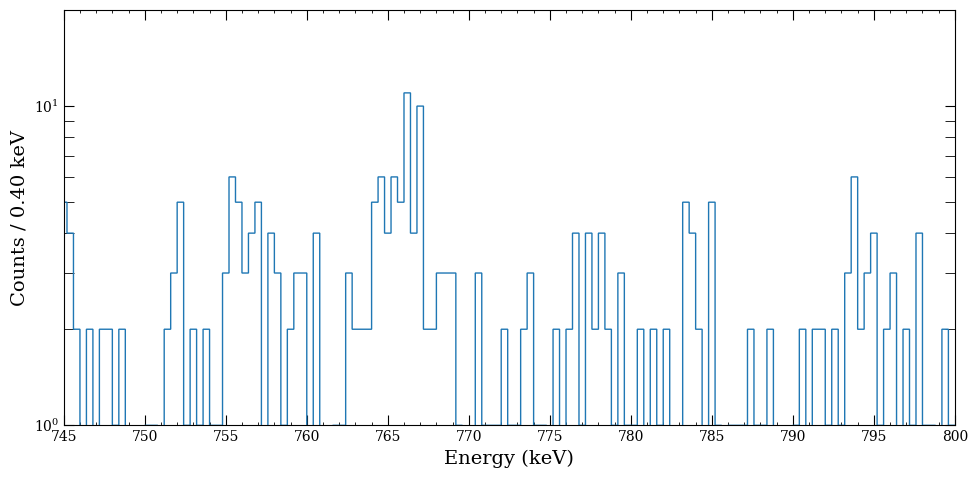

In [159]:

plt.figure(figsize=(10,5))
ax = plt.gca()


dx_major = 5
dx_minor = 1

ax.xaxis.set_major_locator(MultipleLocator(dx_major))
ax.xaxis.set_minor_locator(MultipleLocator(dx_minor))
dy_major = 100
dy_minor = 20

ax.yaxis.set_major_locator(MultipleLocator(dy_major))
ax.yaxis.set_minor_locator(MultipleLocator(dy_minor))

ax.tick_params(axis='x', which='major', length=7, labelsize=10)
#ax.tick_params(axis='x', which='minor', length=4)

ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=7)

# Bin width
db = 0.4
bins_common = np.arange(0,3000+db,db)


c, bc, _ = plt.hist(E_tot, bins = bins_common, 
             weights = Ntot, 
             histtype='step',
            )


db_plot = (bc[1]-bc[0]) 

plt.xlim([745, 800])
plt.ylim([1, 20])
plt.xlabel('Energy (keV)')
plt.ylabel(rf'Counts / {db_plot:.2f} keV')
plt.yscale('log')
#plt.grid(alpha=0.15)
#ax.grid(which='major', linestyle='-', alpha=0.15)
#ax.grid(which='minor', linestyle='--', alpha=0.15)
plt.tight_layout()
#plt.legend(fontsize=15)

plt.savefig("spectrum_50_days.png")
plt.show()


In [160]:
print(sigma_fun(np.array([795])))

[0.91627364]


In [161]:
def gaussian_plus_bg(E, mu, sigma, N, M, B):

    g = (
        N
        * np.exp(-(E - mu)**2 / (2 * sigma**2))
        / (sigma * np.sqrt(2 * np.pi))
    )

    return g + B + M*E


# ============================================================
# DOUBLE GAUSSIAN (COMMON SIGMA) + LINEAR BACKGROUND
# ============================================================

def double_gaussian_plus_bg(E, mu1, N1, mu2, N2, sigma, M, B):

    g1 = (
        N1
        * np.exp(-(E - mu1)**2 / (2 * sigma**2))
        / (sigma * np.sqrt(2 * np.pi))
    )

    g2 = (
        N2
        * np.exp(-(E - mu2)**2 / (2 * sigma**2))
        / (sigma * np.sqrt(2 * np.pi))
    )

    return g1 + g2 +  B + M*E


# ============================================================
# FWHM / SIGMA CONVERSION
# ============================================================

def sigma_to_fwhm(sigma):
    return 2.355 * sigma


def fwhm_to_sigma(fwhm):
    return fwhm / 2.355


# ============================================================
# EXAMPLE DETECTOR RESOLUTION MODEL
# MODIFY WITH YOUR CALIBRATION
# ============================================================




# ============================================================
# MAIN FIT FUNCTION
# ============================================================

def fit_peak(E, counts, center, window=4, plot=True):

    # --------------------------------------------------------
    # ROI SELECTION
    # --------------------------------------------------------

    mask = (E > center - window) & (E < center + window)

    E_roi = E[mask]
    counts_roi = counts[mask]

    # Poisson uncertainties
    errors = np.sqrt(np.maximum(counts_roi, 1))

    sigma_guess = sigma_fun(center)

    # ========================================================
    # DOUBLE PEAK REGION
    # ========================================================

    if 763 <= center <= 770:

        mu1_guess = 765.0
        mu2_guess = 768.356

        # Background estimate
        bg_guess = np.median(counts_roi)

        # Rough net area estimate
        net_counts = np.sum(counts_roi - bg_guess)
        net_counts = max(net_counts, 1)

        p0 = [
            mu1_guess,             # mu1
            net_counts * 0.6,      # N1
            768.6,             # mu2
            5.5,      # N2
            sigma_guess,           # common sigma
            0,
            bg_guess               # offset
        ]

        bounds = ([

                    762,
                    0,
                    768.5,
                    5,
                    sigma_guess*0.8,
                    -100, 
                    0
                ],
                [
                    766,
                    np.inf,
                    769,
                    6,
                    sigma_guess*1.2,
                    100,
                    np.inf
                ])

        popt, pcov = curve_fit(
            double_gaussian_plus_bg,
            E_roi,
            counts_roi,
            p0=p0,
            bounds=bounds,
            sigma = 1/np.sqrt(np.maximum(counts_roi, 1)),
            absolute_sigma=True,
            maxfev=20000,
        )
        #double_results = build_results_double_peak(popt)

        perr = np.sqrt(np.diag(pcov))

        result = {
            "type": "double",

            "mu1": popt[0],
            "N1": popt[1],

            "mu2": popt[2],
            "N2": popt[3],

            "sigma": popt[4],
            "FWHM": sigma_to_fwhm(popt[4]),
            "M" : popt[5],
            "B": popt[6],

            "err_mu1": perr[0],
            "err_N1": perr[1],

            "err_mu2": perr[2],
            "err_N2": perr[3],

            "err_sigma": perr[4],
            "err_FWHM": sigma_to_fwhm(perr[4]),

            "err_M" : perr[5],
            "err_B": perr[6],
        }

        model_fun = lambda x: double_gaussian_plus_bg(x, *popt)

    elif 722 <= center <= 730:

        

        mu1_guess = 724.20
        mu2_guess = 727.72

        mask = (E > ((mu1_guess+mu2_guess)/2) - window) & (E < ((mu1_guess+mu2_guess)/2) + window)

        E_roi = E[mask]
        counts_roi = counts[mask]

        # Poisson uncertainties
        errors = np.sqrt(np.maximum(counts_roi, 1))

        sigma_guess = sigma_fun(center)

        # Background estimate
        bg_guess = np.median(counts_roi)

        # Rough net area estimate
        net_counts = np.sum(counts_roi - bg_guess)
        net_counts = max(net_counts, 1)

        p0 = [
            mu1_guess,             # mu1
            net_counts * 0.3,      # N1
            mu2_guess,             # mu2
            net_counts * 0.7,      # N2
            sigma_guess,           # common sigma,
            0,
            bg_guess               # offset
        ]

        bounds = ([
                    mu1_guess*0.95,
                    0,
                    mu2_guess*0.95,
                    0,
                    sigma_guess*0.8,
                    -100,
                    0
                ],
                [
                    mu1_guess*1.05,
                    np.inf,
                    mu2_guess*1.05,
                    25,
                    sigma_guess*1.2,
                    100,
                    np.inf
                ])

        popt, pcov = curve_fit(
            double_gaussian_plus_bg,
            E_roi,
            counts_roi,
            p0=p0,
            bounds=bounds,
            sigma=errors,
            absolute_sigma=True,
            maxfev=20000,
        )
        #double_results = build_results_double_peak(popt)

        perr = np.sqrt(np.diag(pcov))

        result = {
            "type": "double",

            "mu1": popt[0],
            "N1": popt[1],

            "mu2": popt[2],
            "N2": popt[3],

            "sigma": popt[4],
            "FWHM": sigma_to_fwhm(popt[4]),

            "M" : popt[5],

            "B": popt[6],

            "err_mu1": perr[0],
            "err_N1": perr[1],

            "err_mu2": perr[2],
            "err_N2": perr[3],

            "err_sigma": perr[4],
            "err_FWHM": sigma_to_fwhm(perr[4]),

            "err_M": perr[5],
            "err_B": perr[6],
        }

        model_fun = lambda x: double_gaussian_plus_bg(x, *popt)

    # ========================================================
    # SINGLE PEAK
    # ========================================================

    else:

        bg_guess = np.median(counts_roi)

        net_counts = np.sum(counts_roi - bg_guess)
        net_counts = max(net_counts, 1)

        p0 = [
            center,         # mu
            sigma_guess,    # sigma
            net_counts,     # N
            0,
            bg_guess        # offset
        ]

        bounds = (
            [
                center*0.9,
                sigma_guess*0.8,
                0,
                -100,
                0
            ],
            [
                center *1.1,
                sigma_guess*1.5,
                np.inf,
                100,
                np.inf
            ]
        )

        popt, pcov = curve_fit(
            gaussian_plus_bg,
            E_roi,
            counts_roi,
            p0=p0,
            bounds=bounds,
            sigma=errors,
            absolute_sigma=True,
            maxfev=10000,
        )

        perr = np.sqrt(np.diag(pcov))

        result = {
            "type": "single",

            "mu": popt[0],
            "sigma": popt[1],
            "FWHM": sigma_to_fwhm(popt[1]),
            "N": popt[2],
            "M" : popt[3],
            "B": popt[4],

            "err_mu": perr[0],
            "err_sigma": perr[1],
            "err_FWHM": sigma_to_fwhm(perr[1]),
            "err_N": perr[2],
            "err_M": perr[3],
            "err_B": perr[4],
        }

        model_fun = lambda x: gaussian_plus_bg(x, *popt)

    # ========================================================
    # PLOT
    # ========================================================

    if plot:

        fig, ax = plt.subplots(
            2,
            1,
            figsize=(8, 6),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )

        E_fit = np.linspace(E_roi.min(), E_roi.max(), 1000)

        model_fit = model_fun(E_fit)

        # --------------------------------------------
        # TOP PANEL
        # --------------------------------------------

        ax[0].step(
            E_roi,
            counts_roi,
            where="mid",
            color="black",
            label="Data"
        )

        ax[0].scatter(
            E_roi,
            counts_roi,
            color="black",
            s=10
        )

        ax[0].plot(
            E_fit,
            model_fit,
            color="red",
            lw=2,
            label="Fit"
        )

        # Individual components for double fit
        if result["type"] == "double":

            mu1 = popt[0]
            N1 = popt[1]

            mu2 = popt[2]
            N2 = popt[3]

            sigma = popt[4]

           
            B = popt[5]

            g1 = (
                N1
                * np.exp(-(E_fit - mu1)**2 / (2 * sigma**2))
                / (sigma * np.sqrt(2*np.pi))
            )

            g2 = (
                N2
                * np.exp(-(E_fit - mu2)**2 / (2 * sigma**2))
                / (sigma * np.sqrt(2*np.pi))
            )

            bg =  B

            ax[0].plot(E_fit, g1 + bg, "--", lw=1.5, label="Peak 1")
            ax[0].plot(E_fit, g2 + bg, "--", lw=1.5, label="Peak 2")

        ax[0].set_ylabel(
            f"Counts / {E_roi[1]-E_roi[0]:.3f} keV"
        )

        ax[0].set_title(f"Peak fit @ {center:.2f} keV")

        ax[0].grid(alpha=0.3)

        ax[0].legend()

        # --------------------------------------------
        # RESIDUALS
        # --------------------------------------------

        residuals = counts_roi - model_fun(E_roi)

        ax[1].scatter(
            E_roi,
            residuals,
            s=15
        )

        ax[1].axhline(
            0,
            color="red",
            lw=1
        )

        ax[1].set_xlabel("Energy [keV]")
        ax[1].set_ylabel("Residuals")

        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return result

In [162]:
sigma_fun(860.564)

np.float64(0.9397409988008136)

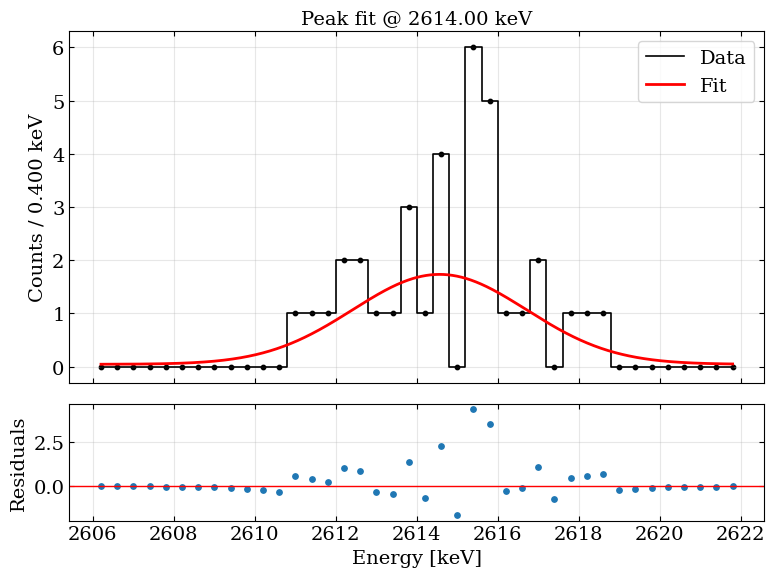

228-Ac
{'type': 'single', 'mu': np.float64(2614.562018653548), 'sigma': np.float64(2.1466061549577087), 'FWHM': np.float64(5.055257494925404), 'N': np.float64(9.090810829598555), 'M': np.float64(1.6351066609061704e-05), 'B': np.float64(5.582125753930004e-10), 'err_mu': np.float64(0.7308593990254474), 'err_sigma': np.float64(0.8508717577980903), 'err_FWHM': np.float64(2.0038029896145026), 'err_N': np.float64(4.226863098345878), 'err_M': np.float64(0.039500721082289955), 'err_B': np.float64(103.20270791285255)}


In [164]:
# ============================================================
# BACKGROUND PEAK FITS
# ============================================================
fit_results = {}

for peak_name, peak_energy in BACKGROUND_PEAKS.items():
    result = fit_peak(
        E_tot,
        Ntot,
        center=peak_energy,
        window=FIT_WINDOW,
        plot=True,
    )

    fit_results[peak_name] = result

    print("=" * 60)
    print(peak_name)
    print(result)

# REGION @ 724 keV

In [165]:
BACKGROUND_PEAKS = {
    "212-Bi + 95-Zr" : 724 , 

}

FIT_WINDOW = 8

In [186]:
def gaussian_plus_bg_224(E, mu, sigma, N, M, B):

    g = (
        N
        * np.exp(-(E - mu)**2 / (2 * sigma**2))
        / (sigma * np.sqrt(2 * np.pi))
    )

    return g + B + M*E


# ============================================================
# DOUBLE GAUSSIAN (COMMON SIGMA) + LINEAR BACKGROUND
# ============================================================

def double_gaussian_plus_bg(E, mu1, N1, mu2, N2, sigma, M, B):

    g1 = (
        N1
        * np.exp(-(E - mu1)**2 / (2 * sigma**2))
        / (sigma * np.sqrt(2 * np.pi))
    )

    g2 = (
        N2
        * np.exp(-(E - mu2)**2 / (2 * sigma**2))
        / (sigma * np.sqrt(2 * np.pi))
    )

    return g1 + g2 +  B + M*E



def fit_peak_double_224(E, counts, center, window, plot=True):


    mu1_guess = 724.20
    mu2_guess = 727.33

    mask = (E > ((mu1_guess+mu2_guess)/2) - window) & (E < ((mu1_guess+mu2_guess)/2) + window)

    E_roi = E[mask]
    counts_roi = counts[mask]

# Poisson uncertainties
    errors = np.sqrt(np.maximum(counts_roi, 1))

    sigma_guess = sigma_fun(center)

    # Background estimate
    bg_guess = np.median(counts_roi)

        # Rough net area estimate
    net_counts = np.sum(counts_roi - bg_guess)
    net_counts = max(net_counts, 1)

    p0 = [
            mu1_guess,             # mu1
            net_counts * 0.3,      # N1
            mu2_guess,             # mu2
            net_counts * 0.7,      # N2
            sigma_guess,           # common sigma,
            0,
            bg_guess               # offset
        ]

    bounds = ([
                    mu1_guess*0.999,
                    0,
                    mu2_guess*0.999,
                    0,
                    sigma_guess*0.8,
                    -100,
                    0
                ],
                [
                    mu1_guess*1.001,
                    np.inf,
                    mu2_guess*1.001,
                    25,
                    sigma_guess*1.2,
                    100,
                    np.inf
                ])

    popt, pcov = curve_fit(
            double_gaussian_plus_bg,
            E_roi,
            counts_roi,
            p0=p0,
            bounds=bounds,
            sigma =1/np.sqrt(np.maximum(counts_roi, 1)),
            #absolute_sigma=True,
            maxfev=20000,
        )
    perr = np.sqrt(np.diag(pcov))

    

    model_fun = lambda x: double_gaussian_plus_bg(x, *popt)


    if plot:

        fig, ax = plt.subplots(
            2,
            1,
            figsize=(8, 6),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )


        E_fit = np.linspace(E_roi.min()  , E_roi.max(), 1000)

        model_fit = model_fun(E_fit)

        # --------------------------------------------
        # TOP PANEL
        # --------------------------------------------

        ax[0].step(
            E_roi,
            counts_roi,
            where="mid",
            color="black",
            label="Data"
        )

        ax[0].scatter(
            E_roi,
            counts_roi,
            color="black",
            s=10
        )

        ax[0].plot(
            E_fit,
            model_fit,
            color="red",
            lw=2,
            label="Fit"
        )


        mu1 = popt[0]
        N1 = popt[1]

        mu2 = popt[2]
        N2 = popt[3]

        sigma = popt[4]

        M = popt[5]   
        B = popt[6]

        g1 = (
                N1
                * np.exp(-(E_fit - mu1)**2 / (2 * sigma**2))
                / (sigma * np.sqrt(2*np.pi))
            )

        g2 = (
                N2
                * np.exp(-(E_fit - mu2)**2 / (2 * sigma**2))
                / (sigma * np.sqrt(2*np.pi))
            )

        bg =  B + M * E_fit

        ax[0].plot(E_fit, g1 + bg, "--", lw=1.5, label="Peak 1")
        ax[0].plot(E_fit, g2 + bg, "--", lw=1.5, label="Peak 2")

        ax[0].set_ylabel(
            f"Counts / {E_roi[1]-E_roi[0]:.3f} keV"
        )

        ax[0].set_title(f"Peak fit @ {center:.2f} keV")

        ax[0].grid(alpha=0.3)

        ax[0].legend()
        #ax[0].set_xlim(721, 730)

        # --------------------------------------------
        # RESIDUALS
        # --------------------------------------------

        residuals = counts_roi - model_fun(E_roi)

        ax[1].scatter(
            E_roi,
            residuals,
            s=15
        )

        ax[1].axhline(
            0,
            color="black",
            ls = '--',
            lw=1
        )
        ax[1].axhline(
            1,
            color="green",
            lw=0.5
        )
        ax[1].axhline(
            -1,
            color="green",
            lw=0.5
        )
        ax[1].axhline(
            2,
            color="orange",
            lw=0.5
        )
        ax[1].axhline(
            -2,
            color="orange",
            lw=0.5
        )
        ax[1].axhline(
            3,
            color="red",
            lw=0.5
        )
        ax[1].axhline(
            -3,
            color="red",
            lw=0.5
        )

        ax[1].set_xlabel("Energy [keV]")
        ax[1].set_ylabel("Residuals")
       # ax[1].set_xlim(721, 730)

        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(popt )
        print(np.sqrt(np.diag(pcov)))

    return 

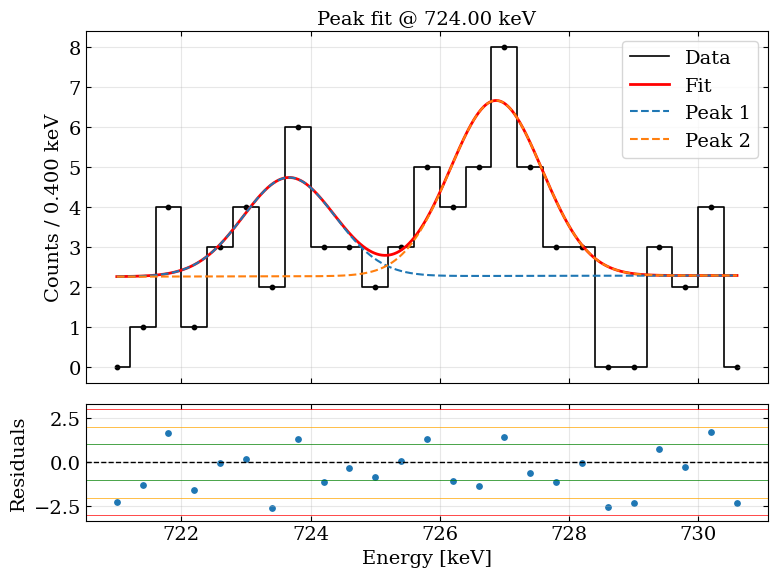

[7.23667296e+02 4.42193391e+00 7.26870282e+02 7.84813051e+00
 7.12130478e-01 3.12387716e-03 2.39443555e-15]
[  0.35645676   2.75857001   0.1720255    2.73840118   0.19148621
   0.15291281 111.17532102]


In [189]:

for peak_name, peak_energy in BACKGROUND_PEAKS.items():
    fit_peak_double_224(
        E_tot,
        Ntot,
        center=peak_energy,
        window=5,
        plot=True,
    )





# 228Ac @ 794 keV

In [190]:
BACKGROUND_PEAKS = {
    "228-Ac" : 911 , 

}

FIT_WINDOW = 8

In [191]:
def gaussian_plus_bg(E, mu, sigma, N, M, B):

    g = (
        N
        * np.exp(-(E - mu)**2 / (2 * sigma**2))
        / (sigma * np.sqrt(2 * np.pi))
    )

    return g + B + M*E


# ============================================================
# MAIN FIT FUNCTION
# ============================================================

def fit_peak_single(E, counts, center, window=4, plot=True):

    # --------------------------------------------------------
    # ROI SELECTION
    # --------------------------------------------------------

    mask = (E > center - window) & (E < center + window)

    E_roi = E[mask]
    counts_roi = counts[mask]

    # Poisson uncertainties
    errors = np.sqrt(np.maximum(counts_roi, 1))

    sigma_guess = sigma_fun(center)



    bg_guess = np.median(counts_roi)

    net_counts = np.sum(counts_roi - bg_guess)
    net_counts = max(net_counts, 1)

    p0 = [
            center,         # mu
            sigma_guess,    # sigma
            net_counts,     # N
            0,
            bg_guess        # offset
        ]

    bounds = (
            [
                center*0.8,
                sigma_guess*0.8,
                0,
                -100,
                0
            ],
            [
                center *1.2,
                sigma_guess*1.5,
                np.inf,
                0,
                np.inf
            ]
        )

    popt, pcov = curve_fit(
            gaussian_plus_bg,
            E_roi,
            counts_roi,
            p0=p0,
            bounds=bounds,
            sigma = 1/np.sqrt(np.maximum(counts_roi, 1)),
            absolute_sigma=True,
            maxfev=10000,
        )

    perr = np.sqrt(np.diag(pcov))
    model_fun = lambda x: gaussian_plus_bg(x, *popt)


    if plot:

        fig, ax = plt.subplots(
            2,
            1,
            figsize=(8, 6),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )

        E_fit = np.linspace(E_roi.min(), E_roi.max(), 1000)

        model_fit = model_fun(E_fit)

        # --------------------------------------------
        # TOP PANEL
        # --------------------------------------------

        ax[0].step(
            E_roi,
            counts_roi,
            where="mid",
            color="black",
            label="Data"
        )

        ax[0].scatter(
            E_roi,
            counts_roi,
            color="black",
            s=10
        )

        ax[0].plot(
            E_fit,
            model_fit,
            color="red",
            lw=2,
            label="Fit"
        )

       
        ax[0].set_ylabel(
            f"Counts / {E_roi[1]-E_roi[0]:.3f} keV"
        )

        ax[0].set_title(f"Peak fit @ {center:.1f} keV")

        ax[0].grid(alpha=0.3)

        ax[0].legend()

        # --------------------------------------------
        # RESIDUALS
        # --------------------------------------------

        residuals = counts_roi - model_fun(E_roi)

        ax[1].scatter(
            E_roi,
            residuals,
            s=15
        )

        ax[1].axhline(
            0,
            color="red",
            lw=1
        )

        ax[1].set_xlabel("Energy [keV]")
        ax[1].set_ylabel("Residuals")

        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(popt)
        print(np.sqrt(np.diag(pcov)))

    return 

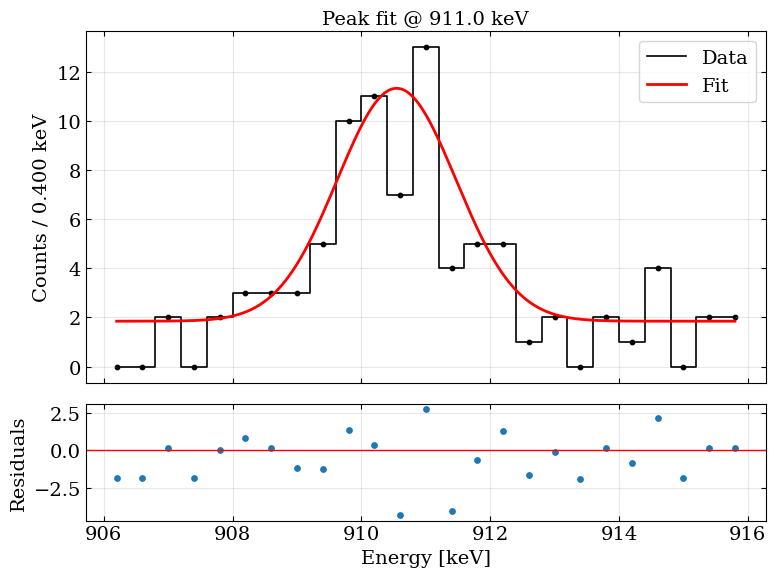

[ 9.10547164e+02  9.22874728e-01  2.19388386e+01 -2.30691780e-15
  1.84684835e+00]
[2.86998153e-02 4.00056479e-02 1.17660098e+00 5.55694566e-02
 5.06679716e+01]


In [192]:

for peak_name, peak_energy in BACKGROUND_PEAKS.items():
    fit_peak_single(
        E_tot,
        Ntot,
        center=peak_energy,
        window = 5,
        plot=True,
    )





# Fit @ 351 keV --> 214-Pb

In [193]:
BACKGROUND_PEAKS = {
    "214-Pb" : 351.93 , 
}

FIT_WINDOW = 8

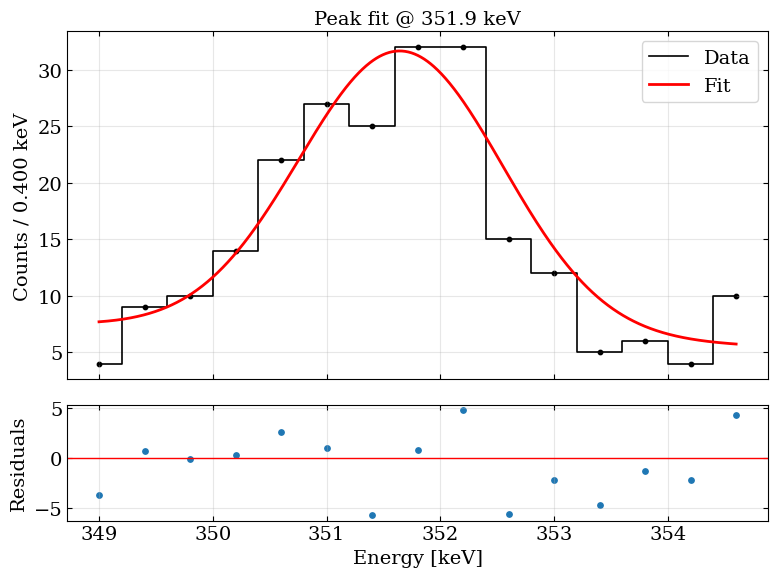

[ 3.51652503e+02  8.95807229e-01  5.63928995e+01 -3.15553472e-01
  1.17513255e+02]
[7.17491209e-03 1.05395693e-02 9.69149288e-01 6.59848323e-02
 2.32503454e+01]


In [194]:

for peak_name, peak_energy in BACKGROUND_PEAKS.items():
    fit_peak_single(
        E_tot,
        Ntot,
        center=peak_energy,
        window = 3,
        plot=True,
    )





# Fit to charcaterize 214Bi @ 609.312 keV

In [195]:
BACKGROUND_PEAKS = {
    "214-Bi" : 609.312 , 
}

FIT_WINDOW = 8

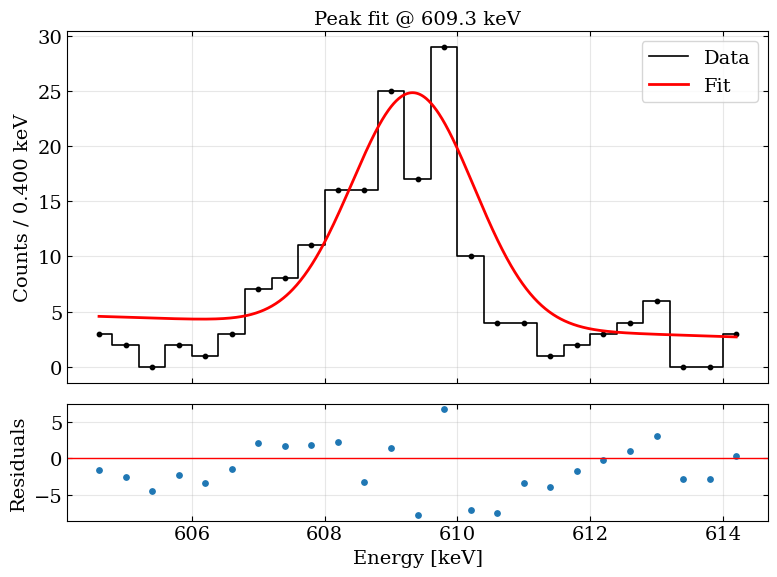

[ 6.09330997e+02  9.17382252e-01  4.88401225e+01 -1.94746799e-01
  1.22303701e+02]
[9.22165321e-03 1.31426811e-02 8.82572642e-01 4.45256141e-02
 2.71460043e+01]


In [197]:

for peak_name, peak_energy in BACKGROUND_PEAKS.items():
    fit_peak_single(
        E_tot,
        Ntot,
        center=peak_energy,
        window = 5,
        plot=True,
    )




# Fit @ 583 keV --> fix 208TL

In [198]:
BACKGROUND_PEAKS = {
    "228-Ac" : 2614 , 

}

FIT_WINDOW = 8

In [199]:
def gaussian_plus_bg(E, mu, sigma, N, M, B):

    g = (
        N
        * np.exp(-(E - mu)**2 / (2 * sigma**2))
        / (sigma * np.sqrt(2 * np.pi))
    )

    return g + B + M*E


# ============================================================
# MAIN FIT FUNCTION
# ============================================================

def fit_peak_single_208Tl(E, counts, center, window=4, plot=True):

    # --------------------------------------------------------
    # ROI SELECTION
    # --------------------------------------------------------

    mask = (E > center - window) & (E < center + window)

    E_roi = E[mask]
    counts_roi = counts[mask]

    # Poisson uncertainties
    errors = np.sqrt(np.maximum(counts_roi, 1))

    sigma_guess = sigma_fun(center)



    bg_guess = np.median(counts_roi)

    net_counts = np.sum(counts_roi - bg_guess)
    net_counts = max(net_counts, 1)

    p0 = [
            center,         # mu
            sigma_guess,    # sigma
            6,     # N
            0,
            0        # offset
        ]

    bounds = (
            [
                center*0.8,
                sigma_guess*0.8,
                5,
                -1,
                0
            ],
            [
                center *1.2,
                sigma_guess*1.5,
                np.inf,
                0,
                np.inf
            ]
        )

    popt, pcov = curve_fit(
            gaussian_plus_bg,
            E_roi,
            counts_roi,
            sigma = 1/np.sqrt(np.maximum(counts_roi, 1)),
            p0=p0,
            bounds=bounds,
            #sigma=errors,
            absolute_sigma=True,
            maxfev=10000,
        )

    perr = np.sqrt(np.diag(pcov))
    model_fun = lambda x: gaussian_plus_bg(x, *popt)


    if plot:

        fig, ax = plt.subplots(
            2,
            1,
            figsize=(8, 6),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )

        E_fit = np.linspace(E_roi.min(), E_roi.max(), 1000)

        model_fit = model_fun(E_fit)

        # --------------------------------------------
        # TOP PANEL
        # --------------------------------------------

        ax[0].step(
            E_roi,
            counts_roi,
            where="mid",
            color="black",
            label="Data"
        )

        ax[0].scatter(
            E_roi,
            counts_roi,
            color="black",
            s=10
        )

        ax[0].plot(
            E_fit,
            model_fit,
            color="red",
            lw=2,
            label="Fit"
        )

       
        ax[0].set_ylabel(
            f"Counts / {E_roi[1]-E_roi[0]:.3f} keV"
        )

        ax[0].set_title(f"Peak fit @ {center:.1f} keV")

        ax[0].grid(alpha=0.3)

        ax[0].legend()

        # --------------------------------------------
        # RESIDUALS
        # --------------------------------------------

        residuals = counts_roi - model_fun(E_roi)

        ax[1].scatter(
            E_roi,
            residuals,
            s=15
        )

        ax[1].axhline(
            0,
            color="red",
            lw=1
        )

        ax[1].set_xlabel("Energy [keV]")
        ax[1].set_ylabel("Residuals")

        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(popt)
        print(np.sqrt(np.diag(pcov)))

    return 

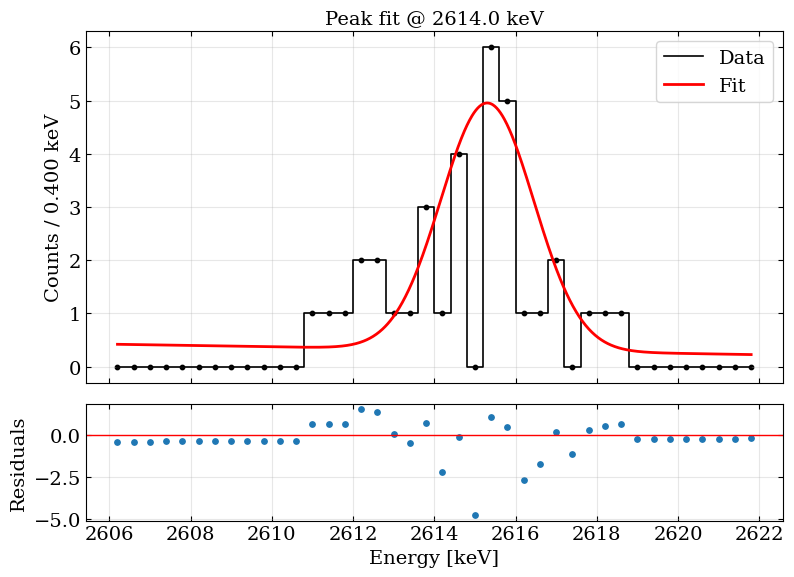

[ 2.61530622e+03  1.14485662e+00  1.33379504e+01 -1.23722965e-02
  3.26630659e+01]
[1.16296631e-01 1.34648330e-01 1.73854612e+00 3.55548333e-02
 9.29103558e+01]


In [200]:

for peak_name, peak_energy in BACKGROUND_PEAKS.items():
    fit_peak_single_208Tl(
        E_tot,
        Ntot,
        center=peak_energy,
        window = 8,
        plot=True,
    )





# Fit @ 765 keV

In [122]:
BACKGROUND_PEAKS = {
    "Tl + Nv + 214Bi" : 351.93 , 
}

FIT_WINDOW = 8

In [ ]:
def gaussian_plus_bg_224(E, mu, sigma, N, M, B):

    g = (
        N
        * np.exp(-(E - mu)**2 / (2 * sigma**2))
        / (sigma * np.sqrt(2 * np.pi))
    )

    return g + B + M*E


# ============================================================
# DOUBLE GAUSSIAN (COMMON SIGMA) + LINEAR BACKGROUND
# ============================================================

def double_gaussian_plus_bg(E, mu1, N1, mu2, N2, sigma, M, B):

    g1 = (
        N1
        * np.exp(-(E - mu1)**2 / (2 * sigma**2))
        / (sigma * np.sqrt(2 * np.pi))
    )

    g2 = (
        N2
        * np.exp(-(E - mu2)**2 / (2 * sigma**2))
        / (sigma * np.sqrt(2 * np.pi))
    )

    return g1 + g2 +  B + M*E



def fit_peak_double_765(E, counts, center, window=4, plot=True):


    mu1_guess = 724.20
    mu2_guess = 727.33

    mask = (E > ((mu1_guess+mu2_guess)/2) - window) & (E < ((mu1_guess+mu2_guess)/2) + window)

    E_roi = E[mask]
    counts_roi = counts[mask]

# Poisson uncertainties
    errors = np.sqrt(np.maximum(counts_roi, 1))

    sigma_guess = sigma_fun(center)

    # Background estimate
    bg_guess = np.median(counts_roi)

        # Rough net area estimate
    net_counts = np.sum(counts_roi - bg_guess)
    net_counts = max(net_counts, 1)

    p0 = [
            mu1_guess,             # mu1
            net_counts * 0.3,      # N1
            mu2_guess,             # mu2
            net_counts * 0.7,      # N2
            sigma_guess,           # common sigma,
            0,
            bg_guess               # offset
        ]

    bounds = ([
                    mu1_guess*0.999,
                    0,
                    mu2_guess*0.999,
                    0,
                    sigma_guess*0.8,
                    -100,
                    0
                ],
                [
                    mu1_guess*1.001,
                    np.inf,
                    mu2_guess*1.001,
                    25,
                    sigma_guess*1.2,
                    100,
                    np.inf
                ])

    popt, pcov = curve_fit(
            double_gaussian_plus_bg,
            E_roi,
            counts_roi,
            p0=p0,
            bounds=bounds,
            sigma=errors,
            absolute_sigma=True,
            maxfev=20000,
        )
    perr = np.sqrt(np.diag(pcov))

    

    model_fun = lambda x: double_gaussian_plus_bg(x, *popt)


    if plot:

        fig, ax = plt.subplots(
            2,
            1,
            figsize=(8, 6),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )


        E_fit = np.linspace(E_roi.min()  , E_roi.max(), 1000)

        model_fit = model_fun(E_fit)

        # --------------------------------------------
        # TOP PANEL
        # --------------------------------------------

        ax[0].step(
            E_roi,
            counts_roi,
            where="mid",
            color="black",
            label="Data"
        )

        ax[0].scatter(
            E_roi,
            counts_roi,
            color="black",
            s=10
        )

        ax[0].plot(
            E_fit,
            model_fit,
            color="red",
            lw=2,
            label="Fit"
        )


        mu1 = popt[0]
        N1 = popt[1]

        mu2 = popt[2]
        N2 = popt[3]

        sigma = popt[4]

        M = popt[5]   
        B = popt[6]

        g1 = (
                N1
                * np.exp(-(E_fit - mu1)**2 / (2 * sigma**2))
                / (sigma * np.sqrt(2*np.pi))
            )

        g2 = (
                N2
                * np.exp(-(E_fit - mu2)**2 / (2 * sigma**2))
                / (sigma * np.sqrt(2*np.pi))
            )

        bg =  B + M * E_fit

        ax[0].plot(E_fit, g1 + bg, "--", lw=1.5, label="Peak 1")
        ax[0].plot(E_fit, g2 + bg, "--", lw=1.5, label="Peak 2")

        ax[0].set_ylabel(
            f"Counts / {E_roi[1]-E_roi[0]:.3f} keV"
        )

        ax[0].set_title(f"Peak fit @ {center:.2f} keV")

        ax[0].grid(alpha=0.3)

        ax[0].legend()
        ax[0].set_xlim(721, 730)

        # --------------------------------------------
        # RESIDUALS
        # --------------------------------------------

        residuals = counts_roi - model_fun(E_roi)

        ax[1].scatter(
            E_roi,
            residuals,
            s=15
        )

        ax[1].axhline(
            0,
            color="black",
            ls = '--',
            lw=1
        )
        ax[1].axhline(
            1,
            color="green",
            lw=0.5
        )
        ax[1].axhline(
            -1,
            color="green",
            lw=0.5
        )
        ax[1].axhline(
            2,
            color="orange",
            lw=0.5
        )
        ax[1].axhline(
            -2,
            color="orange",
            lw=0.5
        )
        ax[1].axhline(
            3,
            color="red",
            lw=0.5
        )
        ax[1].axhline(
            -3,
            color="red",
            lw=0.5
        )

        ax[1].set_xlabel("Energy [keV]")
        ax[1].set_ylabel("Residuals")
        ax[1].set_xlim(721, 730)

        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(popt )
        print(np.sqrt(np.diag(pcov)))

    return 